# Topics Covered
- [1. Build a Simple Workflow or Graph Using LangGraph](#1-build-a-simple-workflow-or-graph-using-langgraph)
- [2. Simple ChatBot using Langgraph](#2-simple-chatbot-using-langgraph)
- [3. State Schema](#3-state-schema)
    - [3.1. State Schema with Typing Module](#31-state-schema-with-typing-module)
    - [3.2. State Schema with Python Dataclass](#32-state-schema-with-python-dataclass)
- [4. Pydantic Data Validation](#4-pydantic-data-validation)
- [5. A more complex graph example](#5-a-more-complex-graph-example)
- [6. Chain Using LangGraph](#6-chain-using-langgraph)
    - [6.1. How to use chat messages as our graph state](#61-how-to-use-chat-messages-as-our-graph-state)
    - [6.2. Using messages as state with Reducers and Tool integration](#62-using-messages-as-state-with-reducers-and-tool-integration)
    -[6.3. Chatbot With Multiple Tools Using Langgraph](#63-chatbot-with-multiple-tools-using-langgraph)

### 1. Build a Simple Workflow or Graph Using LangGraph
#### State
First, define the State of the graph.

The State schema serves as the input schema for all Nodes and Edges in the graph.

Let's use the TypedDict class from python's typing module as our schema, which provides type hints for the keys.

In [1]:
from typing import TypedDict, Literal
import random
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

In [2]:
class State(TypedDict):
    graph_info: str

#### Nodes
Nodes are just python functions.

The first positional argument is the state, as defined above.

Because the state is a TypedDict with schema as defined above, each node can access the key, graph_state, with state['graph_state'].

Each node returns a new value of the state key graph_state.

By default, the new value returned by each node will override the prior state value.

In [3]:
def start_play(state: State)-> dict:
    print("Start Play Node is called")
    return {"graph_info": state["graph_info"] + "I am planning to play "}

def cricket(state:State):
    print("Cricket Node is called")
    return {"graph_info": state["graph_info"] + "Cricket"}

def badminton(state:State):
    print("Badminton Node is called")
    return {"graph_info": state["graph_info"] + "Badminton"}

In [4]:
def random_play(state:State)-> Literal['cricket','badminton']:
    graph_info=state['graph_info']

    if random.random()>0.5:
        return "cricket"
    else:
        return "badminton"

#### Graph Construction
Now, we build the graph from our components defined above.

The StateGraph class is the graph class that we can use.

First, we initialize a StateGraph with the State class we defined above.

Then, we add our nodes and edges.

We use the START Node, a special node that sends user input to the graph, to indicate where to start our graph.

The END Node is a special node that represents a terminal node.

Finally, we compile our graph to perform a few basic checks on the graph structure.

We can visualize the graph as a Mermaid diagram.

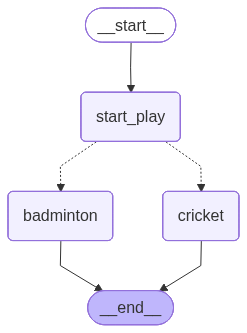

In [5]:
## Build Graph
graph=StateGraph(State)

## Adding the nodes
graph.add_node("start_play",start_play)
graph.add_node("cricket",cricket)
graph.add_node("badminton",badminton)

## Schedule the flow of the graph
graph.add_edge(START,"start_play")
graph.add_conditional_edges("start_play",random_play)
graph.add_edge("cricket",END)
graph.add_edge("badminton",END)

## Compile the graph
graph_builder=graph.compile()

## View
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [6]:
graph_builder.invoke({"graph_info":"Hey My name is Krish"})

Start Play Node is called
Badminton Node is called


{'graph_info': 'Hey My name is KrishI am planning to play Badminton'}

### 2. Simple ChatBot using Langgraph

In [7]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [8]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq

In [9]:
openai_key = os.getenv("OPENAI_API_KEY")
groq_key = os.getenv("GROQ_API_KEY")

# set environment variable for OpenAI API key
if openai_key is not None:
	os.environ["OPENAI_API_KEY"] = openai_key
else:
	raise ValueError("OPENAI_API_KEY environment variable is not set.")

# set environment variable for Groq API key
if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

In [10]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [11]:
llm_openai=ChatOpenAI(model="gpt-4o")
# or
llm_groq=ChatGroq(model="llama-3.1-8b-instant")

In [12]:
def superbot(state:State) -> State: 
    return {"messages":[llm_groq.invoke(state['messages'])]}

In [13]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)

## Edges
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

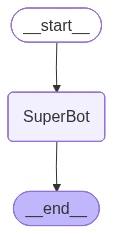

In [14]:
graph_builder=graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [15]:
graph_builder.invoke({'messages': ["Hi,My name is Krish And I like cricket"]})

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='9ea91153-67e7-4216-96c5-ce47aa0ef5e6'),
  AIMessage(content="Nice to meet you, Krish. Cricketer fan, eh? That's awesome. Which team or player is your favorite in the world of cricket? Do you have a favorite format - Test matches, One Day Internationals (ODIs), or Twenty20?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 45, 'total_tokens': 100, 'completion_time': 0.095052546, 'completion_tokens_details': None, 'prompt_time': 0.004066643, 'prompt_tokens_details': None, 'queue_time': 0.067292578, 'total_time': 0.099119189}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd0be-a83a-7912-aa3b-9f0335d699a1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_toke

In [16]:
# streaming response from LLMs
for event in graph_builder.stream({"messages":["Hello My name is KRish"]}):
    print(event)

{'SuperBot': {'messages': [AIMessage(content="Hello KRish, it's nice to meet you. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 41, 'total_tokens': 60, 'completion_time': 0.032289364, 'completion_tokens_details': None, 'prompt_time': 0.003699326, 'prompt_tokens_details': None, 'queue_time': 0.067855257, 'total_time': 0.03598869}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_8f8420ecd7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd0be-ae44-71f3-8cca-8ea2bc3cbabe-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 19, 'total_tokens': 60})]}}


### 3. State Schema
When we define a LangGraph StateGraph, we use a state schema.

The state schema represents the structure and types of data that our graph will use.

All nodes are expected to communicate with that schema.

LangGraph offers flexibility in how you define your state schema, accommodating various Python types and validation approaches!

#### 3.1. State Schema with Typing Module
we can use the TypedDict class from python's typing module.

It allows you to specify keys and their corresponding value types.

But, note that these are type hints.

They can be used by static type checkers (like mypy) or IDEs to catch potential type-related errors before the code is run.

But they are not enforced at runtime!

In [17]:
from typing import TypedDict, Dict
from dataclasses import dataclass
from typing import Literal
import random
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

In [18]:
class TypedDictState(TypedDict):
    name:str
    game:Literal['cricket','badminton']

In [19]:
def play_game(state:TypedDictState) -> Dict[str,str]:
    print("---Play Game node has been called--")
    return {"name":state['name'] + " want to play "}

def cricket(state:TypedDictState) -> Dict[str,str]:
    print("-- Cricket node has been called--")
    return {"name":state["name"] + " cricket","game":"cricket"}

def badminton(state:TypedDictState) -> Dict[str,str]:
    print("-- badminton node has been called--")
    return {"name":state["name"] + " badminton","game":"badminton"}

In [21]:
def decide_play(state:TypedDictState)->Literal["cricket","badminton"]:
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:
        return "cricket"
    else:
        return "badminton"

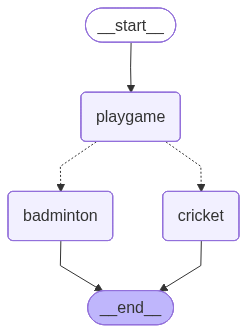

In [22]:
builder=StateGraph(TypedDictState)
builder.add_node("playgame",play_game)
builder.add_node("cricket",cricket)
builder.add_node("badminton",badminton)

## Flow of the graph
builder.add_edge(START,"playgame")
builder.add_conditional_edges("playgame",decide_play)
builder.add_edge("cricket",END)
builder.add_edge("badminton",END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
graph.invoke({"name": "Krish", "game": "cricket"})

---Play Game node has been called--
-- Cricket node has been called--


{'name': 'Krish want to play  cricket', 'game': 'cricket'}

#### 3.2. State Schema with Python Dataclass
Python's dataclasses provide another way to define structured data.
Dataclasses offer a concise syntax for creating classes that are primarily used to store data.

In [24]:
@dataclass
class DataClassState:
    name:str
    game:Literal["badminton","cricket"]

In [25]:
def play_game(state:DataClassState) -> Dict[str,str]:
    print("---Play Game node has been called--")
    return {"name":state.name + " want to play "}

def cricket(state:DataClassState) -> Dict[str,str]:
    print("-- Cricket node has been called--")
    return {"name":state.name + " cricket","game":"cricket"}

def badminton(state:DataClassState) -> Dict[str,str]:
    print("-- badminton node has been called--")
    return {"name":state.name + " badminton","game":"badminton"}

In [26]:
import random
def decide_play(state:DataClassState)->Literal["cricket","badminton"]:
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:
        return "cricket"
    else:
        return "badminton"

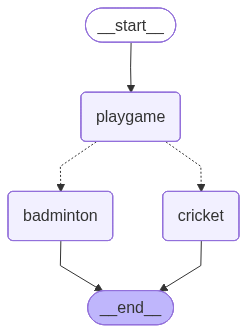

In [27]:
builder=StateGraph(DataClassState)
builder.add_node("playgame",play_game)
builder.add_node("cricket",cricket)
builder.add_node("badminton",badminton)

## Flow of the graph
builder.add_edge(START,"playgame")
builder.add_conditional_edges("playgame",decide_play)
builder.add_edge("cricket",END)
builder.add_edge("badminton",END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
graph.invoke(DataClassState(name="KRish",game="cricket"))

---Play Game node has been called--
-- badminton node has been called--


{'name': 'KRish want to play  badminton', 'game': 'badminton'}

### 4. Pydantic Data Validation

In [29]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel
from IPython.display import Image, display

In [30]:
class State(BaseModel):
    name:str

In [31]:
## node function
def example_node(state:State):
    return {"name":"Hello"}

In [32]:
builder=StateGraph(State)
builder.add_node("example_node",example_node)

builder.add_edge(START,"example_node")
builder.add_edge("example_node",END)

graph=builder.compile()

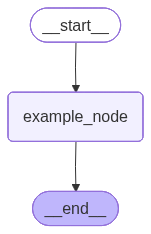

In [33]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
graph.invoke(State(name="Krish"))

{'name': 'Hello'}

### 5. A more complex graph example
This example uses LangGraph to simulate a simple "order fulfillment" process, demonstrating state management, multiple nodes, and conditional branching.The graph processes an order, checks for a valid payment, updates the inventory, and handles different outcomes, such as a successful order or a failed payment.  

#### The order fulfillment workflow:
- The graph has five nodes and processes the following logic:
- An order is received and assigned an order_id.
- The check_payment node checks if the payment is valid.
- If valid, the flow proceeds to process_order and then update_inventory.
- If invalid, the flow goes to the send_payment_failure_email node.
- All paths eventually lead to the send_confirmation_email node, which finalizes the order status.

In [35]:
import operator
from typing import Annotated, List, Literal, TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [36]:
# 1. Define the state object
# The state is a shared "whiteboard" that nodes can read from and write to.
# Using Annotated[list, operator.add] ensures lists are appended, not overwritten.

class OrderState(TypedDict):
    order_id: str
    is_payment_valid: bool
    status: Annotated[List[str], operator.add]
    details: Annotated[List[str], operator.add]


In [37]:
# 2. Define the node functions
def check_payment(state: OrderState):
    """
    Checks the payment status for an order.
    A valid payment is simulated based on the `is_payment_valid` flag.
    """
    if state["is_payment_valid"]:
        print("Payment is valid. Processing order...")
        return {"status": ["payment_valid"]}
    else:
        print("Payment is invalid. Sending failure email...")
        return {"status": ["payment_invalid"]}
    

def process_order(state: OrderState):
    """Processes the order, simulating a step like picking items."""
    print(f"Processing order {state['order_id']}...")
    return {"status": ["order_processed"], "details": [f"Order {state['order_id']} has been picked."]}

def update_inventory(state: OrderState):
    """Simulates updating the inventory and confirms the stock update."""
    print(f"Updating inventory for order {state['order_id']}...")
    return {"status": ["inventory_updated"], 
            "details": [f"Inventory updated for order {state['order_id']}."]}

def send_payment_failure_email(state: OrderState):
    """Sends a notification for a failed payment."""
    print("Sending payment failure email...")
    return {"status": ["payment_failure_email_sent"], "details": ["Email sent regarding failed payment."]}

def send_confirmation_email(state: OrderState):
    """Sends a confirmation email for a completed order."""
    print("Sending order confirmation email...")
    final_status = state["status"][-1]
    return {"status": ["confirmation_email_sent"], 
            "details": [f"Order {state['order_id']} confirmation sent. Final status: {final_status}."]
            }

In [38]:
# 3. Define the conditional logic for routing
def route_payment(state: OrderState) -> Literal["payment_valid", "payment_invalid"]:
    """Determines the next step based on the payment status."""
    if "payment_valid" in state["status"]:
        return "payment_valid"
    else:
        return "payment_invalid"

In [39]:
# 4. Build the graph
# Create a StateGraph instance with the defined state.
workflow = StateGraph(OrderState)

# Add all the nodes to the graph with their associated Python functions.
workflow.add_node("check_payment", check_payment)
workflow.add_node("process_order", process_order)
workflow.add_node("update_inventory", update_inventory)
workflow.add_node("send_payment_failure_email", send_payment_failure_email)
workflow.add_node("send_confirmation_email", send_confirmation_email)

# Set the starting point of the graph.
workflow.set_entry_point("check_payment")

# Add conditional edges based on the payment check.
workflow.add_conditional_edges(
    "check_payment",
    route_payment,
    {
        "payment_valid": "process_order",
        "payment_invalid": "send_payment_failure_email"
    }
)

# Add normal edges for sequential flow.
workflow.add_edge("process_order", "update_inventory")

# Add edges to the final confirmation step from both valid and invalid payment paths.
workflow.add_edge("update_inventory", "send_confirmation_email")
workflow.add_edge("send_payment_failure_email", "send_confirmation_email")

# Connect the final step to the END node.
workflow.add_edge("send_confirmation_email", END)

# Compile the graph for execution.
app = workflow.compile()


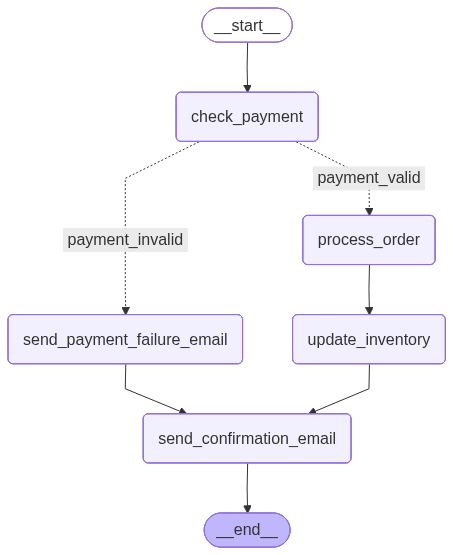

In [40]:
display(Image(app.get_graph().draw_mermaid_png()))

In [41]:
# 5. Run the example
# Example 1: Successful Order
print("--- Running successful order ---")
successful_order_state = app.invoke({"order_id": "ORD_123", "is_payment_valid": True, 
                                     "status": [], "details": []})
print("\nFinal State for successful order:")
print(successful_order_state)

--- Running successful order ---
Payment is valid. Processing order...
Processing order ORD_123...
Updating inventory for order ORD_123...
Sending order confirmation email...

Final State for successful order:
{'order_id': 'ORD_123', 'is_payment_valid': True, 'status': ['payment_valid', 'order_processed', 'inventory_updated', 'confirmation_email_sent'], 'details': ['Order ORD_123 has been picked.', 'Inventory updated for order ORD_123.', 'Order ORD_123 confirmation sent. Final status: inventory_updated.']}


In [42]:
# Example 2: Failed Order
print("\n--- Running failed order ---")
failed_order_state = app.invoke({"order_id": "ORD_456", "is_payment_valid": False, 
                                 "status": [], "details": []})
print("\nFinal State for failed order:")
print(failed_order_state)


--- Running failed order ---
Payment is invalid. Sending failure email...
Sending payment failure email...
Sending order confirmation email...

Final State for failed order:
{'order_id': 'ORD_456', 'is_payment_valid': False, 'status': ['payment_invalid', 'payment_failure_email_sent', 'confirmation_email_sent'], 'details': ['Email sent regarding failed payment.', 'Order ORD_456 confirmation sent. Final status: payment_failure_email_sent.']}


### 6. Chain Using LangGraph
In this section we will see how we can build a simple chain using Langgraph that uses 4 important concepts

- How to use chat messages as our graph state
- How to use chat models in graph nodes
- How to bind tools to our LLM in chat models
- How to execute the tools call in our graph nodes 

In [43]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [44]:
from langchain_core.messages import AIMessage,HumanMessage
from pprint import pprint
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI

In [45]:
openai_key = os.getenv("OPENAI_API_KEY")
groq_key = os.getenv("GROQ_API_KEY")

# set environment variable for OpenAI API key
if openai_key is not None:
	os.environ["OPENAI_API_KEY"] = openai_key
else:
	raise ValueError("OPENAI_API_KEY environment variable is not set.")

# set environment variable for Groq API key
if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

#### 6.1. How to use chat messages as our graph state
##### Messages

We can use messages which can be used to capture different roles within a conversation.
LangChain has various message types including HumanMessage, AIMessage, SystemMessage and ToolMessage.
These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

Every message have these important components.

- content - content of the message
- name - Specify the name of author
- response_metadata - optionally, a dict of metadata (e.g., often populated by model provider for AIMessages)

In [46]:
messages = []
messages.append(AIMessage(content="Please tell me how can I help", name="LLMModel"))
messages.append(HumanMessage(content="I want to learn coding", name="Krish"))
messages.append(AIMessage(content="Which programming language you want to learn", name="LLMModel"))
messages.append(HumanMessage(content="I want to learn python programming language", name="Krish"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help
================================ Human Message =================================
Name: Krish

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Which programming language you want to learn
================================ Human Message =================================
Name: Krish

I want to learn python programming language


#### Chat Models
We can use the sequence of message as input with the chatmodels using LLM's and OPENAI.

In [47]:
llm_openai=ChatOpenAI(model="gpt-4o")
# or
llm_groq=ChatGroq(model="llama-3.1-8b-instant")

In [48]:
result=llm_openai.invoke(messages)

In [49]:
result.response_metadata

{'token_usage': {'completion_tokens': 547,
  'prompt_tokens': 59,
  'total_tokens': 606,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 0,
   'rejected_prediction_tokens': 0},
  'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
 'model_provider': 'openai',
 'model_name': 'gpt-4o-2024-08-06',
 'system_fingerprint': 'fp_18e61aa3bc',
 'id': 'chatcmpl-DHM4CURwEyAELSAdE9RL4DcBA27a1',
 'service_tier': 'default',
 'finish_reason': 'stop',
 'logprobs': None}

#### Tools
Tools can be integrated with the LLM models to interact with external systems. External systems can be API's, third party tools.

Whenever a query is asked the model can choose to call the tool and this query is based on the 
natural language input and this will return an output that matches the tool's schema

In [50]:
def add(a:int,b:int)-> int:
    """ Add a and b
    Args:
        a (int): first int
        b (int): second int

    Returns:
        int
    """
    return a+b

In [51]:
### Binding tool with llm
llm_with_tools=llm_groq.bind_tools([add])
tool_call=llm_with_tools.invoke([HumanMessage(content=f"What is 2 plus 2",name="Krish")])

In [52]:
# Safely access tool_calls attribute of the AIMessage
print(getattr(tool_call, "tool_calls", None))

[{'name': 'add', 'args': {'a': 2, 'b': 2}, 'id': 'cccam0hxm', 'type': 'tool_call'}]


#### 6.2. Using messages as state with Reducers and Tool integration
We can use reducer functions to address this.

Reducers allow us to specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before.

But, to append messages, we can use the pre-built add_messages reducer.

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our messages key with the add_messages reducer function as metadata.

In [53]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

In [54]:
class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

In [55]:
initial_messages=[]
initial_messages.append(AIMessage(content=f"Please tell me how can I help",name="LLMModel"))
initial_messages.append(HumanMessage(content=f"I want to learn coding",name="Krish"))
initial_messages

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Krish')]

In [56]:
ai_message=AIMessage(content=f"Which programming language you want to learn",name="LLMModel")
ai_message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Which programming language you want to learn


In [57]:
### Reducers add_messages is to append instead of override
updated_messages = add_messages(initial_messages, ai_message)
for msg in updated_messages:
    msg.pretty_print()  # type: ignore

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help
================================ Human Message =================================
Name: Krish

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Which programming language you want to learn


In [65]:
# tool function
def add(a:int,b:int)-> int:
    """ Add a and b
    Args:
        a (int): first int
        b (int): second int

    Returns:
        int
    """
    return a+b

In [66]:
# bind the tool with llm
tools=[add]
llm_with_tools=llm_groq.bind_tools(tools)

In [67]:
## chatbot node functionality
def llm_tool(state:State):
    return {"messages":[llm_with_tools.invoke(state['messages'])]}

In [68]:
builder=StateGraph(State)

# Add nodes
builder.add_node("llm_tool",llm_tool)
builder.add_node("tools",ToolNode(tools))

## Add Edge
builder.add_edge(START,"llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)
graph_builder = builder.compile()

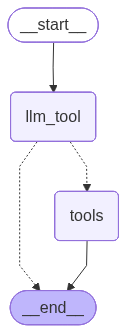

In [69]:
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [63]:
## invocation
messages = graph_builder.invoke({"messages": [HumanMessage(content="What is 2 plus 2")]})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (xw9gy8874)
 Call ID: xw9gy8874
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4


In [70]:
messages = graph_builder.invoke({"messages": [HumanMessage(content="What is Machine Learning?")]})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is Machine Learning?
================================== Ai Message ==================================

brave_search={"title": "Machine Learning","description": "Machine learning is a field of study that focuses on the use of algorithms and statistical models to enable machines to perform a specific task without using explicit instructions, relying on patterns and trends in the data to make decisions."}<function=brave_search>


#### 6.3. Chatbot With Multiple Tools Using Langgraph
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [71]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [72]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from pprint import pprint
### Tavily Search Tool
from langchain_tavily import TavilySearch
from langchain_core.messages import AIMessage, HumanMessage
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [73]:
groq_key = os.getenv("GROQ_API_KEY")
tavily_key = os.getenv("TAVILY_API_KEY")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

if tavily_key is not None:
    os.environ["TAVILY_API_KEY"] = tavily_key
else:
    raise ValueError("TAVILY_API_KEY environment variable is not set.")

In [74]:
api_wrapper_arxiv = ArxivAPIWrapper(
    top_k_results=2, 
    doc_content_chars_max=500
) # type: ignore

arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)

In [75]:
arxiv.invoke("Attention iss all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [76]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500) # type: ignore
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)

In [77]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nML fi'

In [78]:
tavily = TavilySearch()
tavily.invoke("Provide me the recent AI news for Sept 7 2025")

{'query': 'Provide me the recent AI news for Sept 7 2025',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://medium.com/last-week-in-ai/last-week-in-ai-september-7-2025-e1e095432d0d',
   'title': 'Last Week in AI — September 7, 2025 | by Jonathan Fulton - Medium',
   'content': 'Korean startup Naver acquires European AI lab for $500M (Financial News, Aug 31) — Naver expanded into Europe with a major AI lab acquisition.',
   'score': 0.8763069,
   'raw_content': None},
  {'url': 'https://www.oreateai.com/blog/latest-ai-news-september-2025/e0120ec90498aa338418edc6f7e7d0cb',
   'title': 'Latest Ai News September 2025 - Oreate AI Blog',
   'content': "September 2025 saw significant advancements in AI including OpenAI's GPT-6 launch and breakthroughs in ethical algorithms aimed at reducing",
   'score': 0.8565368,
   'raw_content': None},
  {'url': 'https://www.ptechpartners.com/2025/10/07/emerging-ai-news-roundup-for-september-2025-ai-psychology-re

In [79]:
### Combine all the tools in the list
tools=[arxiv,wiki,tavily]

In [88]:
## Initialize my LLM model
llm_openai=ChatOpenAI(model="gpt-4o")
# or
llm_groq=ChatGroq(model="llama-3.1-8b-instant")

In [89]:
# bind the tool with llm
llm_with_tools=llm_groq.bind_tools(tools)

In [90]:
tools_call = llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

In [91]:
getattr(tools_call, 'tool_calls', None)

[{'name': 'tavily_search',
  'args': {'query': 'recent AI news', 'time_range': 'day', 'topic': 'news'},
  'id': 'jednfypfp',
  'type': 'tool_call'}]

In [92]:
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [93]:
### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

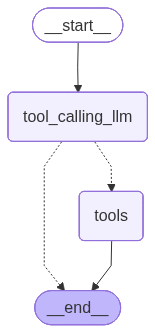

In [94]:
# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [95]:
messages = graph.invoke({"messages": [HumanMessage(content="1706.03762")]})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (5ef0c3by3)
 Call ID: 5ef0c3by3
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [96]:
messages = graph.invoke({"messages": [HumanMessage(content="Provide me the top 10 recent AI news for today")]})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for today
================================== Ai Message ==================================
Tool Calls:
  tavily_search (ym9bs204s)
 Call ID: ym9bs204s
  Args:
    query: AI news today
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news today", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://markets.businessinsider.com/news/stocks/ai-labs-introduces-ai-assisted-crypto-trading-platform-focused-on-data-analysis-and-automated-execution-1035908256", "title": "AI Labs Introduces AI-Assisted Crypto Trading Platform Focused on Data Analysis and Automated Execution - markets.businessinsider.com", "score": 0.58721006, "published_date": "Mon, 09 Mar 2026 01:45:09 GMT", "content": "My Markets Watchlist\n\nMarket

In [97]:
messages=graph.invoke({"messages":[HumanMessage(content="What is machine learning")]})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (v8dssn0t7)
 Call ID: v8dssn0t7
  Args:
    query: machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
ML fi
